# Marco Lopez - Homework 2

## Part 1: Data Generator

In [1]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import math

random.seed(53)

# Supports the following arguments:
# A list of functions, a true function (y), a range to sample x, number of samples to generate, noise-level parameter

def generate_noisy_dataset(functions, true_function, x_range, n_samples, noise_level):
    noisy_dataset = []
    for _ in range(n_samples):
        sample_row = []
        # Generates a random x sample within range
        rand_x = random.uniform(x_range[0], x_range[1])
        sample_row.append(rand_x)
        
        # Generates random noise
        rand_noise = random.uniform(-noise_level, noise_level)
        
        # Generates function value for all functions 
        for func in functions:
            sample_row.append(func(rand_x))
        
        # Calculates y
        y = true_function(rand_x) + rand_noise
        sample_row.append(y)
        
        # Adds row to the noisy dataset
        noisy_dataset.append(sample_row)
    
    # Column names
    columns = ["x"] + [f"func{i+1}" for i in range(len(functions))] + ["y"]
    # Returns final noisy dataset
    return pd.DataFrame(noisy_dataset, columns = columns)

In [2]:
# Test example
data = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: math.log(x), x_range = [0.0, 1.0], n_samples = 10, noise_level = 0.1)

In [3]:
data

,x,func1,func2,y
0,0.617141,0.380864,0.235047,-0.404629
1,0.456487,0.208381,0.095123,-0.741914
2,0.936981,0.877934,0.822608,-0.060980
3,0.733840,0.538521,0.395189,-0.263858
4,0.858187,0.736484,0.632041,-0.245575
5,0.169292,0.028660,0.004852,-1.676734
6,0.746802,0.557713,0.416501,-0.339756
7,0.742443,0.551221,0.409250,-0.363962
8,0.360237,0.129771,0.046748,-1.032810
9,0.228815,0.052356,0.011980,-1.547203


## Part 2: Linear Regression

In [4]:
# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

In [5]:
print(X)
print(y)

[[0.61714148 0.3808636  0.23504673]
 [0.45648722 0.20838058 0.09512307]
 [0.9369813  0.87793396 0.82260771]
 [0.73384017 0.5385214  0.39518863]
 [0.85818662 0.73648427 0.63204094]
 [0.16929219 0.02865985 0.00485189]
 [0.74680204 0.55771329 0.41650142]
 [0.74244286 0.5512214  0.4092504 ]
 [0.36023712 0.12977078 0.04674825]
 [0.22881478 0.0523562  0.01197987]]
[-0.40462927 -0.74191362 -0.06097999 -0.26385754 -0.24557521 -1.67673395
 -0.33975553 -0.36396195 -1.03280952 -1.54720272]


In [6]:
# Implement fit function 
# Function takes in a training dataset
# Outputs the linear regression weight vector

def fit(X_train, y_train):
    X = np.array(X_train)
    y = np.array(y_train)
    
    # Add a column of 1s for the intercept
    X = np.column_stack((np.ones(X.shape[0]), X))
    
    # Compute B with linear regression closed form solution
    B = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    
    return B

In [7]:
# Implement predict function
# Function takes in weight vector and test dataset
# Output corresponding predictions

def predict(weights, X_test):
    # Add a column of 1s for the intercept
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))
    
    # Calculate predictions
    predictions = X_test.dot(weights)
    
    return predictions

In [8]:
# Implement evaluate_model function
# Function takes predictions and the true outputs 
# Returns the RMSE

def evaluate_model(predictions, y_test):
    return np.sqrt(np.mean((y_test - predictions) ** 2))


### Training testing and evaluating linear regression


In [9]:
# Create data set
data = generate_noisy_dataset(functions = [], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

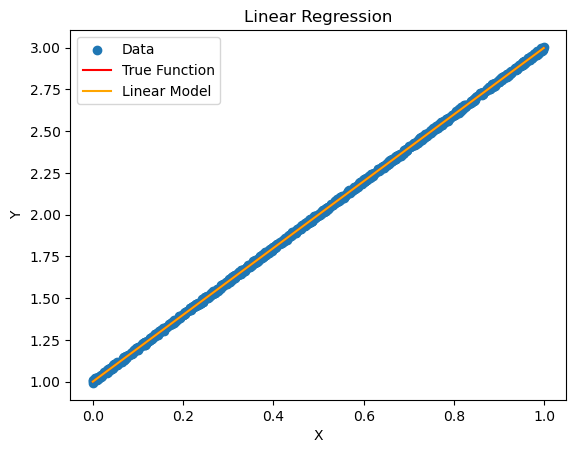

In [10]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X.min(), X.max(), 500)

# True function
true_y = 2 * x_values + 1

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X, y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [11]:
# Create data set
data = generate_noisy_dataset(functions = [], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

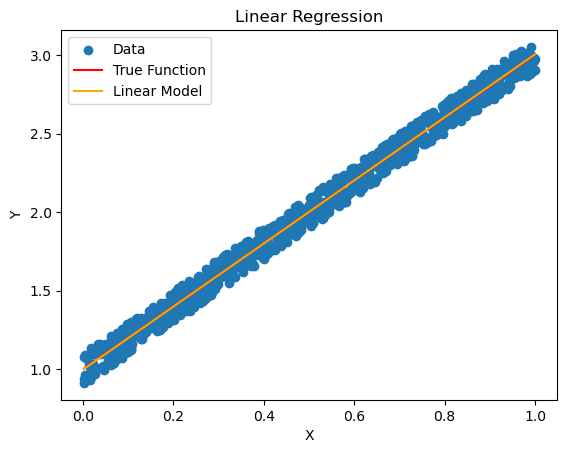

In [12]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X.min(), X.max(), 500)

# True function
true_y = 2 * x_values + 1

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X, y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [13]:
# Create data set
data = generate_noisy_dataset(functions = [], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

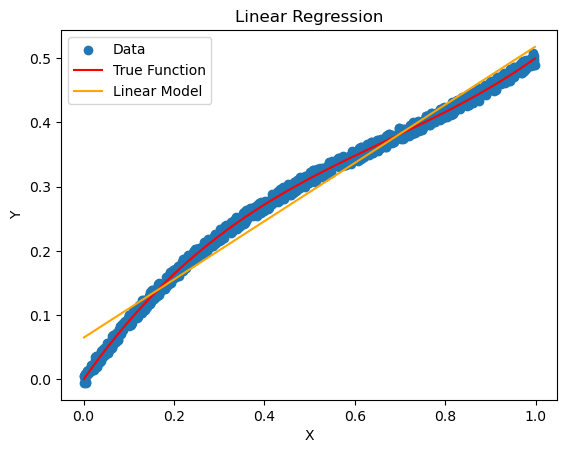

In [14]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X.min(), X.max(), 500)

# True function
true_y = 0.5 * (x_values)**3 - (x_values)**2 + (x_values)

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X, y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [15]:
# Create data set
data = generate_noisy_dataset(functions = [], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

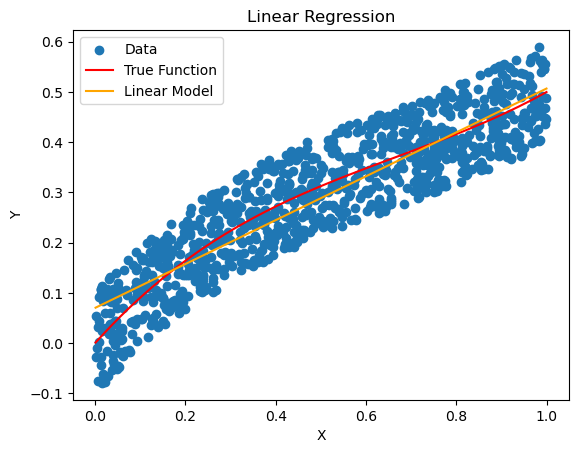

In [16]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X.min(), X.max(), 500)

# True function
true_y = 0.5 * (x_values)**3 - (x_values)**2 + (x_values)

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X, y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

### Repeating linear regression experiments with added artificial columns $x^2$ and $x^3$

In [29]:
# Create data set
data = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

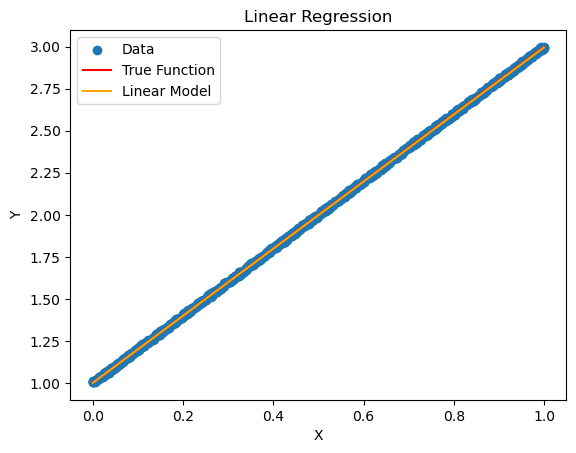

In [30]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# True function
true_y = 2 * x_values + 1

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X[:, 0], y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [32]:
# Create data set
data = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

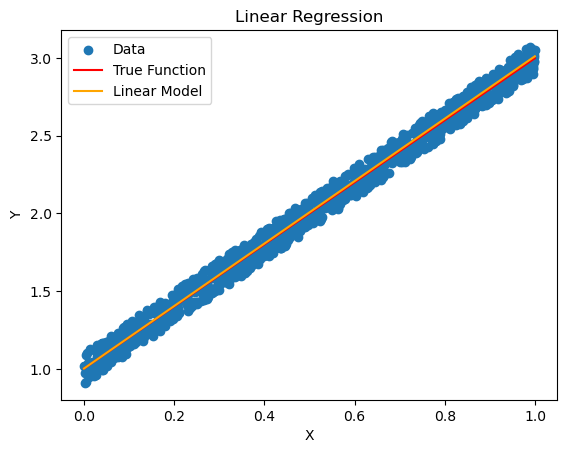

In [33]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# True function
true_y = 2 * x_values + 1

# Linear model using the calculated weights
model_y = weights[0] + weights[1] * x_values

# Scatter plot of the data
plt.scatter(X[:, 0], y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [41]:
# Create data set
data = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

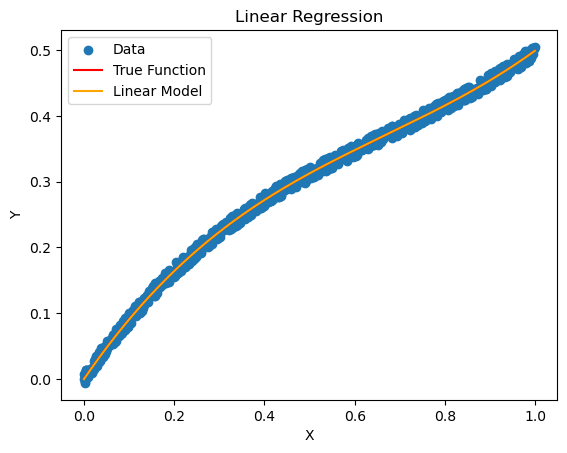

In [42]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# True function
true_y = 0.5 * (x_values)**3 - (x_values)**2 + (x_values)

# Linear model using the calculated weights
model_y = np.zeros(len(x_values))

for i in range(len(weights)):
    model_y += weights[i] * x_values**i

# Scatter plot of the data
plt.scatter(X[:, 0], y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [43]:
# Create data set
data = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

# Split data into X and y
data = np.array(data)
X = data[:, :-1]
y = data[:, -1]

# Split into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 53)

# Calculate the weights
weights = fit(X_train, y_train)

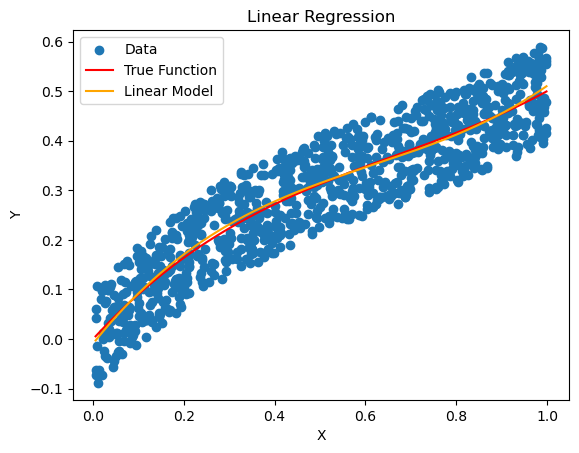

In [44]:
# Plot creation

# X values for plotting the functions
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# True function
true_y = 0.5 * (x_values)**3 - (x_values)**2 + (x_values)

# Linear model using the calculated weights
model_y = np.zeros(len(x_values))

for i in range(len(weights)):
    model_y += weights[i] * x_values**i

# Scatter plot of the data
plt.scatter(X[:, 0], y, label="Data")

# Plot true function
plt.plot(x_values, true_y, color = "red", label="True Function")

# Plot linear regression model
plt.plot(x_values, model_y, color = "orange", label="Linear Model")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

### Reporting error of linear regression models

In [47]:
# Different setups:

data1 = generate_noisy_dataset(functions = [], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

data2 = generate_noisy_dataset(functions = [], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

data3 = generate_noisy_dataset(functions = [], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

data4 = generate_noisy_dataset(functions = [], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

data5 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

data6 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 2*x + 1, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)

data7 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.01)

data8 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)


datasets = [data1, data2, data3, data4, data5, data6, data7, data8]

for i, data in enumerate(datasets, start=1):
    data = np.array(data)

    X = data[:, :-1]
    y = data[:, -1]

    weights = fit(X, y)
    
    if X.shape[1] == 1:
        x_test = np.array([[10]])
    else:
        x_test = np.array([[10, 10**2, 10**3]])

    print(weights)
    
    prediction = predict(weights, x_test)[0]

    if i in [1, 2, 5, 6]:
        actual = (2*10)+1
    else:
        actual = 0.5*(10**3)-(10**2)+10

    error = abs(actual - prediction)

    print(f"Data {i}: Error = {error}")

[0.9998039 2.0003221]
Data 1: Error = 0.0030248648272674927
[0.99907745 2.00255045]
Data 2: Error = 0.024581899268937946
[0.0652839  0.45202755]
Data 3: Error = 405.41444058617327
[0.06789402 0.44769821]
Data 4: Error = 405.4551238941588
[ 0.99901841  2.00500376 -0.00774125  0.00351198]
Data 5: Error = 2.786912658527015
[ 1.00033282  1.96101159  0.08887177 -0.05418416]
Data 6: Error = 45.686538088967154
[ 1.29630937e-04  9.99578688e-01 -9.97874650e-01  4.97312677e-01]
Data 7: Error = 2.478871121094187
[-2.07941102e-04  1.00699473e+00 -1.02380017e+00  5.16551028e-01]
Data 8: Error = 14.240750647959885


In [48]:
cubic_data1 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data2 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data3 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data4 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5, lambda x: x**6], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data5 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5, lambda x: x**6, lambda x: x**7], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data6 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5, lambda x: x**6, lambda x: x**7, lambda x: x**8], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data7 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5, lambda x: x**6, lambda x: x**7, lambda x: x**8, lambda x: x**9], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)
cubic_data8 = generate_noisy_dataset(functions = [lambda x: x**2, lambda x: x**3, lambda x: x**4, lambda x: x**5, lambda x: x**6, lambda x: x**7, lambda x: x**8, lambda x: x**9, lambda x: x**10], true_function = lambda x: 0.5*x**3 - x**2 + x, x_range = [0.0, 1.0], n_samples = 1000, noise_level = 0.1)


In [50]:
cubic_datasets = [
    cubic_data1,
    cubic_data2,
    cubic_data3,
    cubic_data4,
    cubic_data5,
    cubic_data6,
    cubic_data7,
    cubic_data8
]

degrees = range(3, 11)

train_errors = []
test_errors = []

for data in cubic_datasets:
    data = np.array(data)

    X = data[:, :-1]
    y = data[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=53
    )

    weights = fit(X_train, y_train)

    train_predictions = predict(weights, X_train)
    test_predictions = predict(weights, X_test)

    train_errors.append(
        evaluate_model(train_predictions, y_train)
    )

    test_errors.append(
        evaluate_model(test_predictions, y_test)
    )

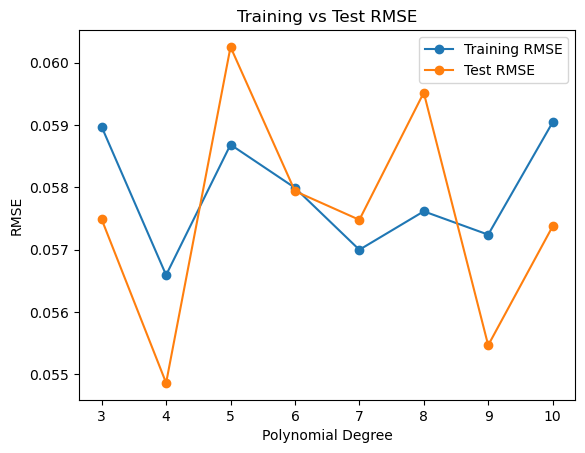

In [51]:
plt.plot(degrees, train_errors, marker="o", label="Training RMSE")
plt.plot(degrees, test_errors, marker="o", label="Test RMSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Training vs Test RMSE")
plt.xticks(degrees)
plt.legend()
plt.show()

## Part 3: Regression Tree

In [17]:
import numpy as np

class RegressionTree:
    # Fits the regression tree using training data
    def fit(self, dataset, min_records):
        self.training_data = dataset
        self.tree = build_tree(dataset, min_records)
        return self.tree
    
    # Use top-down recursive divide and conquer strategy for building the tree
    def build_tree(dataset, min_records):
        # Stop if the node is too small for a split, make a leaf
        if len(dataset) < min_records:
            return np.mean(dataset[:, -1])
        
        feature, value, score = find_best_split(dataset)
        
        # If there is no split found, make a leaf
        if feature is None:
            return np.mean(dataset[:, -1])
        
        left = dataset[dataset[:, feature] <= value]
        right = dataset[dataset[:, feature] > value]
        
        # Returns split feature/value and makes recursive call for left and right sides of tree
        return {"feature": feature, "value": value, "left": build_tree(left, min_records), 
                "right": build_tree(right, min_records)}
    
    # Finds the best split for a regression tree
    def find_best_split(dataset):
        # Initialization
        best_score = float("inf")
        best_feature = None
        best_value = None
        
        X = dataset[:, :-1]
        y = dataset[:, -1]
        
        # Loop through every feature
        for feature in range(X.shape[1]):
            # Obtain possible split values for the feature
            values = np.unique(X[:, feature])
            for value in values:
                # Split into left and right side
                left = dataset[X[:, feature] <= value]
                right = dataset[X[:, feature] > value]
                
                if len(left) == 0 or len(right) == 0:
                    continue

                score = split_score(left[:, -1], right[:, -1])
                
                # Keeps score if it is better than previous best score
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_value = value
                    
        return best_feature, best_value, best_score
    
    # Calculates the split score given y-values for left and right sides
    def split_score(y_left, y_right):
        n = len(y_left) + len(y_right)
        # Score formula
        score = (len(y_left)/n) * np.var(y_left) + (len(y_right)/n) * np.var(y_right)
        return score
    
    # Make a prediction on an input X 
    def predict(self, X):
        predictions = []
        
        for row in X:
            node = self.tree
            
            # Traverse the tree until reaching a leaf, then return result
            while isinstance(node, dict):
                if row[node["feature"]] <= node["value"]:
                    node = node["left"]
                else:
                    node = node["right"]
            
            # Append the leaf
            predictions.append(node)
            
        return np.array(predictions)
    
    # Show the tree split points and generate a line plot showing the predictions of the tree
    def visualize(self):
        split_points = []
        
        def get_split_points(node):
            if isinstance(node, dict):
                split_points.append(node["value"])
                get_split_points(node["left"])
                get_split_points(node["right"])
        
        get_split_points(self.tree)
        
        x_min = self.training_data[:, 0].min()
        x_max = self.training_data[:, 0].max()
        x_values = np.linspace(x_min, x_max, 500).reshape(-1, 1)
        
        # Predictions for tree for the x values
        predictions = self.predict(x_values)
        
        # Plot the predictions
        plt.plot(x_values[:, 0], predictions)
        
        # Plot the tree split points
        for split in split_points:
            plt.axvline(split, linestyle="--")
        
        # Show the training data
        plt.scatter(
            self.training_data[:, 0],
            self.training_data[:, -1]
        )
        
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Regression Tree")
        plt.show()
